In [1]:
import os
# Set this to "1" to disable torch.compile globally
# os.environ["TORCH_COMPILE_DISABLE"] = "1"
import torch
import torch.nn as nn

import numpy as np
from typing import NamedTuple
import matplotlib.pyplot as plt
from scipy.stats import gamma, poisson

from models.utils import build_warmup_epochs
from models.inn import RealNVP,RealNVPSummary
from models.regressionNetwork import RegressionNetwork, train_regression_network

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

from tqdm import tqdm
import torch.nn.utils as utils

In [2]:
dataset = np.load("small_dataset.npz")

seed = 67
print(dataset)
foot = dataset["foot"]

# pad leg with a 1 to make it 2 elemental
leg_pre = dataset["leg"]
leg = np.random.normal(0,1,(leg_pre.shape[0],2))
leg[:,0]= leg_pre.flatten()

# flatten foot
foot = foot.reshape((foot.shape[0],-1)) # flatten(1)?

NpzFile 'small_dataset.npz' with keys: foot, leg


In [23]:
dataset = np.load("big_dataset.npz") #TODO: what are we training here///!

seed = 67
print(dataset)
foot = dataset["foot"]

# pad leg with a 1 to make it 2 elemental
leg_pre = dataset["height"] * 0.45
print(f"{leg.shape=}")
leg = np.random.normal(0,1,(leg_pre.shape[0],2))
leg[:,0]= leg_pre.flatten()

# flatten foot
foot = foot.reshape((foot.shape[0],-1)) # flatten(1)?


NpzFile 'big_dataset.npz' with keys: foot, com, height
leg.shape=(100000, 2)


In [24]:


print(f"{foot.shape}")
print(f"{leg.shape}")

assert foot.shape[0] == leg.shape[0]
N = foot.shape[0]
indices = np.arange(N)

# 2. Shuffle the indices in-place using a generator for better control

rng = np.random.default_rng(seed)
rng.shuffle(indices)

# 3. Calculate the split point
split_point = int(N * 0.8)

# 4. Slice the shuffled array into two vectors
train_indices = indices[:split_point]
test_indices = indices[split_point:]

# declare final arrays
train_foot = foot[train_indices]
train_leg = leg[train_indices]


test_foot = foot[test_indices]
test_leg = leg[test_indices]
print(test_foot.shape,test_leg.shape)

(100000, 306)
(100000, 2)
(20000, 306) (20000, 2)


In [25]:
# create dataloaders:
from torch.utils.data import DataLoader,TensorDataset
dtype = torch.float32
train_tensor_leg = torch.tensor(train_leg).to(dtype)
train_tensor_foot = torch.tensor(train_foot).to(dtype)
test_tensor_leg = torch.tensor(test_leg).to(dtype)
test_tensor_foot = torch.tensor(test_foot).to(dtype)

train_foot_mean = train_tensor_foot.mean()
train_foot_std = train_tensor_foot.std()
train_leg_mean = train_tensor_leg.mean(0,keepdim=True)
train_leg_std = train_tensor_leg.std(0,keepdim=True)

print(train_foot_mean,train_foot_std,train_leg_mean,train_leg_std)

train_tensor_leg = (train_tensor_leg - train_leg_mean) / train_leg_std
train_tensor_foot = (train_tensor_foot - train_foot_mean) / train_foot_std
test_tensor_leg = (test_tensor_leg - train_leg_mean) / train_leg_std
test_tensor_foot = (test_tensor_foot - train_foot_mean) / train_foot_std


train_datatensor = TensorDataset(train_tensor_leg,train_tensor_foot)
test_datatensor = TensorDataset(test_tensor_leg,test_tensor_foot)

def create_dataloaders(batch_size,num_workers = 11):
    train_loader = DataLoader(
                train_datatensor,
                shuffle=True,
                batch_size=batch_size,
                num_workers=11,
                pin_memory=True,
                persistent_workers=True,
                drop_last=True # otherwise, some instances are weighed higher
            )

    test_loader = DataLoader(
                test_datatensor,
                shuffle=False, # unnecesarry
                batch_size=batch_size, # OPT: increase
                num_workers=max(num_workers // 2,4),
                pin_memory=True,
                persistent_workers=True,
                
            )
    return train_loader,test_loader


tensor(-0.0217) tensor(0.2552) tensor([[ 0.7900, -0.0030]]) tensor([[0.0309, 0.9981]])


In [26]:
# print input sizes for model
train_loader = create_dataloaders(32)[0]
leg,foot = next(iter(train_loader))
print(foot.shape,leg.shape)


torch.Size([32, 306]) torch.Size([32, 2])


In [76]:
from torch import GradScaler
from models.inn import CouplingBlock
@torch.compile()
def calculate_loss(model: RealNVPSummary, output):
    loss = torch.zeros((), requires_grad=True, device=device)
    # for block in model.realNVP.blocks: # use for summary network
    for block in model.realNVP.blocks:
        block: CouplingBlock
        loss = loss - block.block_det
    loss += output.pow(2).sum() / 2  # sum over all axis
    return loss / output.size(0)  # mean over batch


def train_inn_cond(
    model: RealNVP,
    train_loader: torch.utils.data.DataLoader,
    test_loader: torch.utils.data.DataLoader,
    optim: torch.optim.Optimizer,
    scaler: GradScaler,
    lr_scheduler: torch.optim.lr_scheduler.LRScheduler,
    epochs: int,
    history,
    batch_size=128,
):
    """
    model: A inn
    train_set_fn: a function that returns X,Y
    with:
    X: the hidden parameter that we want a posterior for later.
    Y: the condition (like observations that will be available at inference time)

    # scaler = GradScaler("cuda", enabled=(device.type == 'cuda'))
    """
    history["train_loss"] = history.get("train_loss", [])
    history["test_loss"] = history.get("test_loss", [])
    model.train()
    pbar = tqdm(range(epochs), desc="Training",leave=True)
    for epoch in pbar:
        train_epoch_loss = torch.zeros((1,), requires_grad=False, device=device)
        test_epoch_loss = torch.zeros((1,), requires_grad=False, device=device)
        train_epoch_length = len(train_loader)
        test_epoch_length = len(test_loader)
        # for now, define a epoch as 100 iterations, because
        # we have no train set size yet.
        
        for leg, foot in train_loader:
            leg: torch.Tensor
            foot: torch.Tensor
            X, Y = leg.to(device), foot.to(device)  # TODO: nonblocking
            optim.zero_grad()
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                #print(X.shape,Y.shape)
                output = model.forward(X, Y)
                # y is used for condition, x is input (see docstring)
                loss = calculate_loss(model, output)
            scaler.scale(loss).backward()
            scaler.unscale_(optim)
            utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            scaler.step(optim)
            scaler.update()
            train_epoch_loss += loss.mean()

        with torch.no_grad():
            model.eval()
            for leg, foot in test_loader:
                leg: torch.Tensor
                foot: torch.Tensor
                X, Y = leg.to(device), foot.to(device)  # TODO: nonblocking
                with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                    #print(X.shape,Y.shape)
                    output = model.forward(X, Y)
                    loss = calculate_loss(model, output)


                test_epoch_loss += loss.mean()
            # print(loss.mean().item())

        model.train()
        train_avg_epoch_loss = (train_epoch_loss / train_epoch_length).item()
        test_avg_epoch_loss = (test_epoch_loss / test_epoch_length).item()
        # print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_epoch_loss:.4f}", end="\r")
        pbar.set_postfix(train_loss=train_avg_epoch_loss,test_loss=test_avg_epoch_loss)
        history["train_loss"].append(train_avg_epoch_loss)
        history["test_loss"].append(test_avg_epoch_loss)
        lr_scheduler.step()
    model.eval()
    return


In [77]:
# TODO: normalize inputs
input_size = 2  #
observable_size = 51 * 6  # maybe use the spacial structure of the data
reduced_obs_size = 12

# model = RealNVP(
#     input_size=input_size,
#     hidden_size=hidden_size,
#     blocks=num_coup_blocks,
#     condition_size=observable_size,
# )
model = RealNVPSummary(
    input_size=input_size,
    condition_size=observable_size,
    reduced_condition_size=reduced_obs_size,
    s_hidden=256,
    s_layers=3,
    r_hidden=64,
    r_blocks=8,
)
# model = RealNVPSummary(input_size=input_size,condition_size=observable_size,reduced_condition_size=reduced_obs_size,s_hidden=256,s_layers=3,r_hidden=32,r_blocks=6)


model.to(device)
model = torch.compile(model, mode="max-autotune", fullgraph=True)

num_epochs = 100
lr_warmup_epochs = 10
init_lr = 5e-3
weight_decay = 1e-4
optimizer = torch.optim.AdamW(model.parameters(), init_lr, weight_decay=weight_decay)
history = {}

batch_size = 32
train_loader, test_loader = create_dataloaders(batch_size)

scaler = torch.GradScaler("cuda", enabled=(device.type == "cuda"))
lr_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, build_warmup_epochs(lr_warmup_epochs, num_epochs)
)


train_inn_cond(
    model,
    train_loader=train_loader,
    test_loader=test_loader,
    optim=optimizer,
    scaler=scaler,
    lr_scheduler=lr_scheduler,
    epochs=num_epochs,
    history=history,
    batch_size=None,
)

Training:   0%|          | 0/100 [00:00<?, ?it/s]AUTOTUNE addmm(32x12, 32x256, 256x12)
strides: [0, 1], [256, 1], [1, 256]
dtypes: torch.float16, torch.float16, torch.float16
  bias_addmm 0.0041 ms 100.0% 
  addmm 0.0068 ms 60.7% 
SingleProcess AUTOTUNE benchmarking takes 0.0425 seconds and 0.0004 seconds precompiling for 2 choices
Training: 100%|██████████| 100/100 [15:44<00:00,  9.44s/it, test_loss=-0.504, train_loss=-1]      


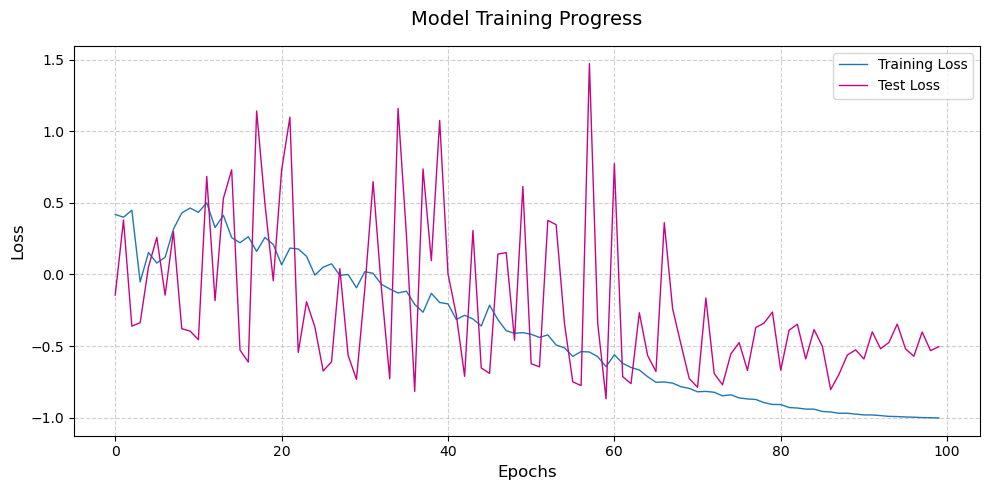

In [78]:
import matplotlib.pyplot as plt
model.eval()
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
#plt.yscale("log")
plt.show()

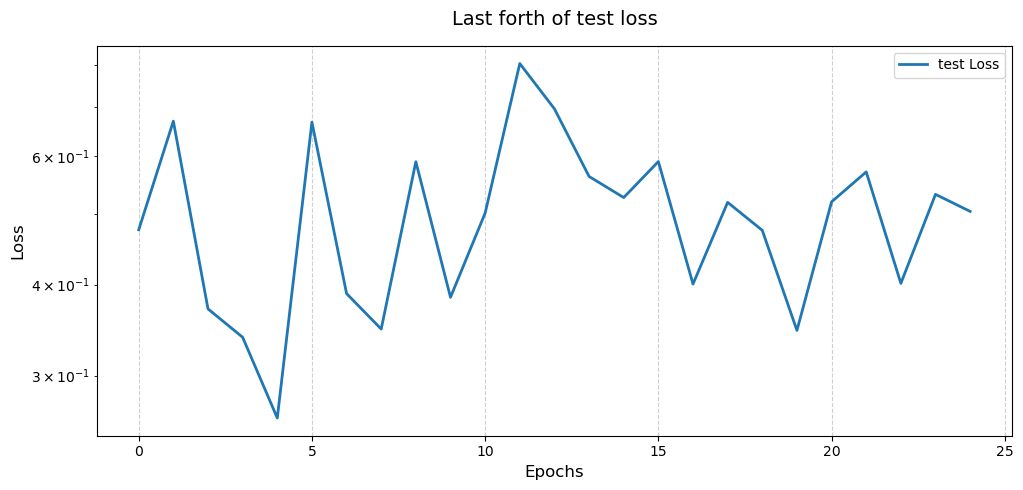

In [79]:
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(-np.array(history["test_loss"][len(history["test_loss"])//4 * 3: ]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=2,           # Slightly thicker line
         label='test Loss')

# 3. Add context and labels
plt.title('Last forth of test loss', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.yscale("log")
plt.show()

In [80]:
# import torch

def compute_mmd(x, y, sigma=1.0):
    """
    Computes the Maximum Mean Discrepancy (MMD) between two sets of samples.
    Args:
        x: Tensor of shape [n, d] (Samples from Distribution P)
        y: Tensor of shape [m, d] (Samples from Distribution Q)
        sigma: Bandwidth of the RBF kernel
    """
    # 1. Compute distance matrix (n+m, n+m)
    z = torch.cat([x, y], dim=0)
    # Efficient pairwise distance calculation: ||a-b||^2 = ||a||^2 + ||b||^2 - 2<a,b>
    dist_matrix = torch.cdist(z, z, p=2)**2
    
    # 2. Apply Gaussian Kernel
    kernel_matrix = torch.exp(-dist_matrix / (2 * sigma**2))
    
    # 3. Extract sub-matrices
    n = x.size(0)
    m = y.size(0)
    
    k_xx = kernel_matrix[:n, :n]
    k_yy = kernel_matrix[n:, n:]
    k_xy = kernel_matrix[:n, n:]
    
    # 4. Compute MMD^2 (Unbiased estimator)
    # Subtracting the diagonal (self-distances) for k_xx and k_yy
    mmd2 = (k_xx.sum() - n) / (n * (n - 1)) + \
           (k_yy.sum() - m) / (m * (m - 1)) - \
           2 * k_xy.mean()
           
    return mmd2

# Example Usage
x = torch.randn(100, 2)  # Mean 0
y = torch.randn(100, 2) + 0.5  # Mean 0.5
loss = compute_mmd(x, y)
print(f"MMD: {loss.item():.4f}")

MMD: 0.0444


AUTOTUNE addmm(80000x12, 80000x256, 256x12)
strides: [0, 1], [256, 1], [1, 256]
dtypes: torch.float32, torch.float32, torch.float32
  bias_addmm 0.2447 ms 100.0% 
  addmm 0.2458 ms 99.6% 
SingleProcess AUTOTUNE benchmarking takes 0.0876 seconds and 0.0001 seconds precompiling for 2 choices


torch.Size([80000, 2])
Train Set: latent.std(0)=tensor([1.0822, 1.0905])
torch.cov(latent.T)=tensor([[1.1711, 0.1356],
        [0.1356, 1.1891]])


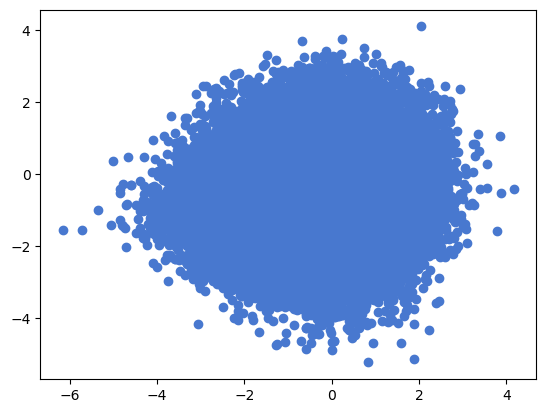

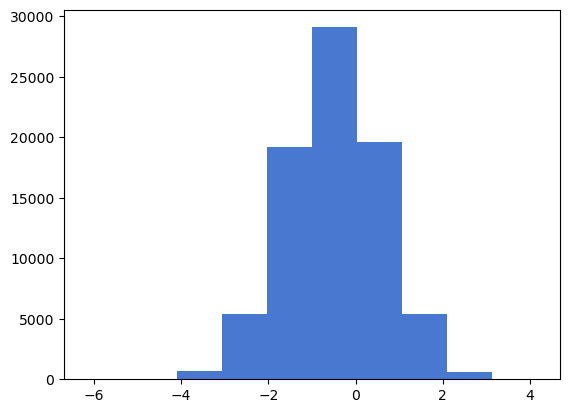

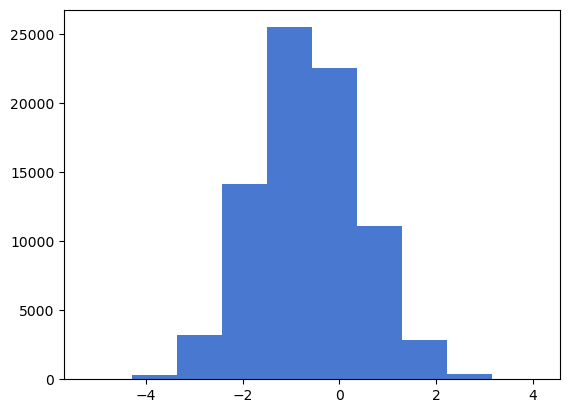

In [81]:
with torch.no_grad():
    latent = model.forward(train_tensor_leg.to(device),train_tensor_foot.to(device)).cpu()
    print(latent.shape)
    print(f"Train Set: {latent.std(0)=}")
    (print(f"{torch.cov(latent.T)=}"))
    plt.scatter(latent[:,0],latent[:,1])
    plt.show()
    plt.hist(latent[:,0])
    plt.show()
    plt.hist(latent[:,1])
    plt.show()

Test Set: latent.std(0)=tensor([1.0722, 1.0955])


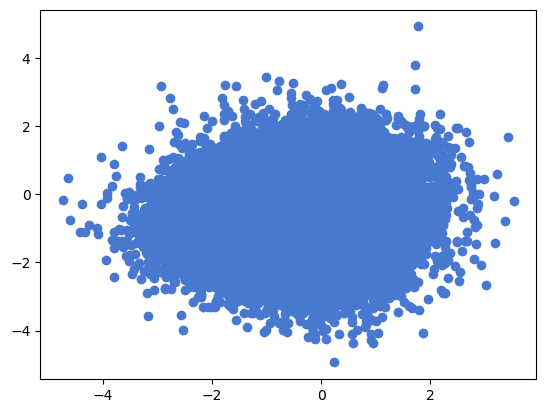

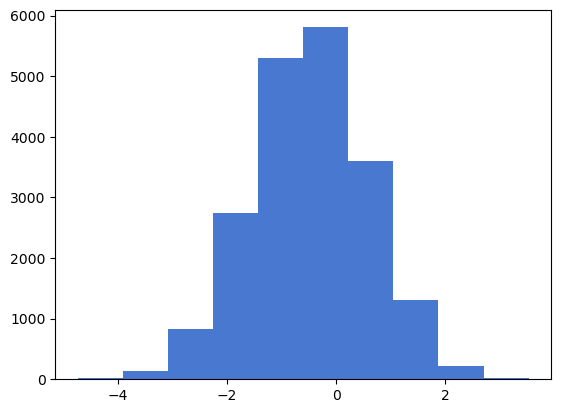

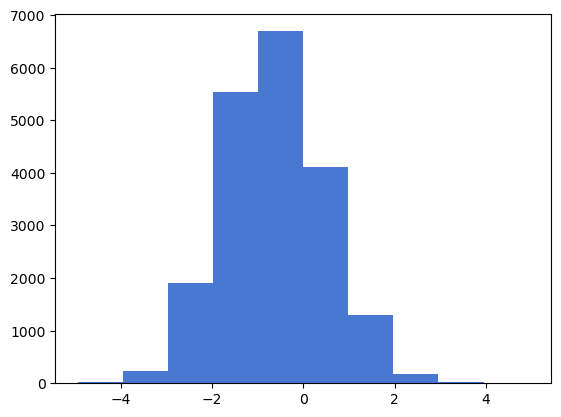

In [82]:

with torch.no_grad():
    latent = model.forward(test_tensor_leg.to(device),test_tensor_foot.to(device)).cpu()
    print(f"Test Set: {latent.std(0)=}")
    plt.scatter(latent[:,0],latent[:,1])
    plt.show()
    plt.hist(latent[:,0])
    plt.show()
    plt.hist(latent[:,1])
    plt.show()

(array([2.0000e+00, 1.2000e+01, 4.4000e+01, 1.0100e+02, 3.3900e+02,
        9.3300e+02, 2.0040e+03, 3.7310e+03, 6.4510e+03, 9.3720e+03,
        1.1906e+04, 1.3579e+04, 1.3769e+04, 1.1990e+04, 9.5590e+03,
        6.7650e+03, 4.3910e+03, 2.5900e+03, 1.4040e+03, 6.3000e+02,
        2.4100e+02, 1.1400e+02, 4.9000e+01, 1.5000e+01, 9.0000e+00]),
 array([0.66046988, 0.67112963, 0.68178939, 0.69244915, 0.7031089 ,
        0.71376866, 0.72442841, 0.73508817, 0.74574793, 0.75640768,
        0.76706744, 0.7777272 , 0.78838695, 0.79904671, 0.80970646,
        0.82036622, 0.83102598, 0.84168573, 0.85234549, 0.86300525,
        0.873665  , 0.88432476, 0.89498451, 0.90564427, 0.91630403,
        0.92696378]),
 <BarContainer object of 25 artists>)

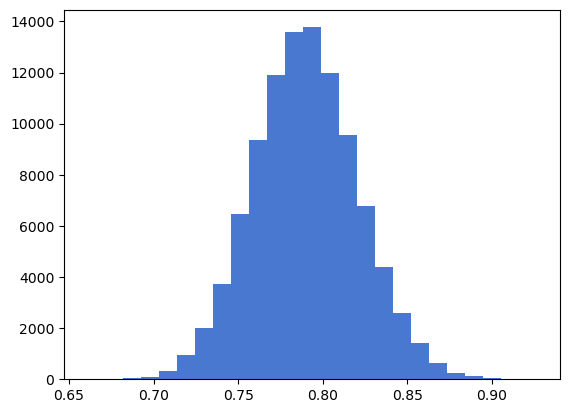

In [83]:
# visualize the dataset leg
plt.hist(leg_pre,bins=25)

In [84]:
res  = model.reverse(torch.normal(0,1,(1000,2)).to(device) ,train_tensor_foot[:1000].to(device) )

In [85]:
corrected = res.cpu() * train_leg_std + train_leg_mean
corrected = corrected.detach()[:,0].flatten()

(array([  3.,   7.,   8.,  11.,  31.,  42.,  62.,  79.,  83.,  90., 119.,
         98.,  89.,  61.,  73.,  48.,  33.,  22.,  12.,  15.,   6.,   6.,
          0.,   1.,   1.]),
 array([0.71056962, 0.71760178, 0.72463399, 0.73166615, 0.73869836,
        0.74573052, 0.75276273, 0.75979489, 0.76682711, 0.77385926,
        0.78089142, 0.78792363, 0.79495579, 0.80198801, 0.80902016,
        0.81605232, 0.82308453, 0.83011675, 0.8371489 , 0.84418106,
        0.85121328, 0.85824543, 0.86527765, 0.8723098 , 0.87934196,
        0.88637418]),
 <BarContainer object of 25 artists>)

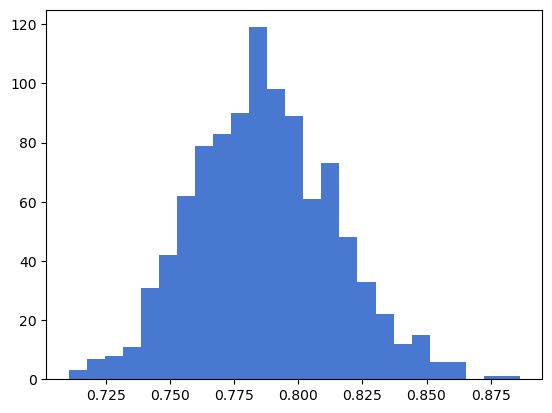

In [86]:
plt.hist(corrected,bins=25)


(array([  6.,  15.,  69., 163., 237., 251., 151.,  71.,  30.,   7.]),
 array([-0.13087674, -0.10437523, -0.07787372, -0.05137222, -0.02487071,
         0.0016308 ,  0.02813231,  0.05463382,  0.08113533,  0.10763684,
         0.13413835]),
 <BarContainer object of 10 artists>)

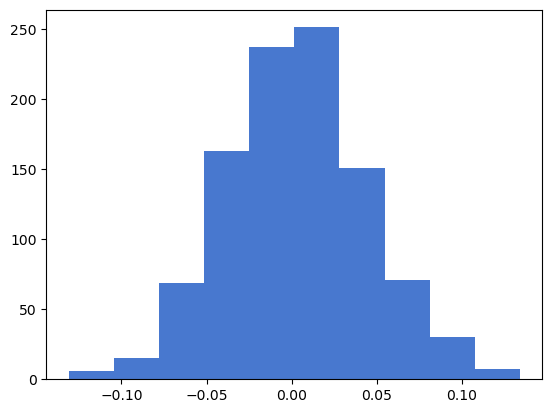

In [87]:
plt.hist((leg_pre[:1000] - corrected.numpy()).flatten() )

In [ ]:
plt.scatter(np.arange(20),corrected[:20].flatten())
plt.scatter(np.arange(20),leg_pre[:20].flatten())
#TODO: copy code from model_realnvp_single.ipynb to visualize confidence

NameError: name 'plt' is not defined

In [100]:
filename_model_params = "saved_model_test.model"
filename_model_hyperparams = "saved_model_test.def"
torch.save(model.state_dict(), filename_model_params)
model_hyperparams_dict = {
    "input_size": model.realNVP.input_size,
    "condition_size": model.summary.input_size,
    "reduced_condition_size": model.realNVP.condition_size,
    "s_hidden": model.summary.encoder_layers[0].weight.shape[0],
    "s_layers": model.summary.layers,
    "r_hidden": model.realNVP.blocks[0].scale_net[0].weight.shape[0],
    "r_blocks": len(model.realNVP.blocks),
}
torch.save(model_hyperparams_dict,filename_model_hyperparams)


In [101]:
init_dict = torch.load(filename_model_hyperparams)
print(init_dict)
loaded_dict = torch.load(filename_model_params)
model = RealNVPSummary(**init_dict)
model = torch.compile(model)
model: RealNVPSummary
model.load_state_dict(loaded_dict)

{'input_size': 2, 'condition_size': 306, 'reduced_condition_size': 12, 's_hidden': 256, 's_layers': 3, 'r_hidden': 12, 'r_blocks': 8}


<All keys matched successfully>